
# Lab 4: การพัฒนาแบบจำลอง Machine Learning สำหรับการจำแนกพื้นที่ป่าด้วยข้อมูลภาพถ่ายดาวเทียม

**ชื่อ-นามสกุล:** นายสุรนาจ เครือวาท  
**รหัสนักศึกษา:** 6606614847  
**รายวิชา:** ภม.337 การพัฒนาโปรแกรมเพื่อการวิเคราะห์ข้อมูลเชิงพื้นที่

**พื้นที่ศึกษา:** จังหวัดจันทบุรี (`Chanthaburi`)  


## 1) ติดตั้งและ import ไลบรารี

In [ ]:

# ถ้ายังไม่เคยติดตั้งใน Colab ให้เอา # ออก 1 ครั้ง
# !pip install rasterio geopandas scikit-learn folium matplotlib pandas numpy shapely pyproj

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import rowcol
from rasterio.windows import Window
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pyproj import Transformer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 6)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) กำหนดตำแหน่งไฟล์ข้อมูล
### รูปแบบข้อมูลที่ใช้ในโน้ตบุ๊กนี้
1. **Raster**: ใช้ไฟล์หลายแบนด์เพียงไฟล์เดียว คือ `Chanthaburi.tif`  
   โดยอ้างอิงลำดับแบนด์ของ Sentinel-2 ดังนี้
   - Band 3  = Green
   - Band 4  = Red
   - Band 8  = NIR
   - Band 11 = SWIR

2. **CSV จุดตัวอย่าง**: มีคอลัมน์อย่างน้อย
   - `longitude`
   - `latitude`
   - `label`




In [ ]:

# ปรับ path ให้ตรงกับ Drive ของคุณ
DATA_DIR = Path("/content/drive/MyDrive/BackupRSProject/Study_area")

# จากที่คุณใช้งานอยู่จริง ไฟล์ raster ชื่อว่า "Chanthaburi" และ CSV ชื่อดังนี้
RASTER_PATH = DATA_DIR / "Chanthaburi"
SAMPLES_CSV = DATA_DIR / "sample_points_chanthaburi_verified_like.csv"

print("Files in folder:")
print(os.listdir(DATA_DIR))
print()
print(f"raster : {RASTER_PATH} | exists = {RASTER_PATH.exists()}")
print(f"samples: {SAMPLES_CSV} | exists = {SAMPLES_CSV.exists()}")

if not RASTER_PATH.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ Raster: {RASTER_PATH}")

if not SAMPLES_CSV.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ CSV: {SAMPLES_CSV}")


Files in folder:
['Chanthaburi', 'sample_points_chanthaburi_1000.csv', 'Untitled', 'classification_result_block.tif', 'sample_points_chanthaburi_verified_like.csv', 'classification_result_block_classes.json']

raster : /content/drive/MyDrive/BackupRSProject/Study_area/Chanthaburi | exists = True
samples: /content/drive/MyDrive/BackupRSProject/Study_area/sample_points_chanthaburi_verified_like.csv | exists = True


## 3) โหลดข้อมูล Raster และแสดง Metadata


ในตัวอย่างนี้ใช้ไฟล์ `Chanthaburi.tif` ซึ่งเป็น Raster หลายแบนด์  
โดยเลือกใช้แบนด์สำคัญสำหรับงานจำแนกพื้นที่ดังนี้:

- **Green** = Band 3
- **Red** = Band 4
- **NIR** = Band 8
- **SWIR** = Band 11

In [ ]:

with rasterio.open(RASTER_PATH) as src:
    meta = src.meta.copy()
    descriptions = src.descriptions

    print("=== Raster Metadata ===")
    for k, v in meta.items():
        print(f"{k}: {v}")

    print("\nRaster shape:", (src.height, src.width))
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Band count:", src.count)
    print("Descriptions:", descriptions)


=== Raster Metadata ===
driver: GTiff
dtype: float32
nodata: -inf
width: 9285
height: 11609
count: 26
crs: EPSG:32647
transform: | 10.00, 0.00, 791170.00|
| 0.00,-10.00, 1476390.00|
| 0.00, 0.00, 1.00|

Raster shape: (11609, 9285)
CRS: EPSG:32647
Transform: | 10.00, 0.00, 791170.00|
| 0.00,-10.00, 1476390.00|
| 0.00, 0.00, 1.00|
Band count: 26
Descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE')


## 4) หาเลข band จากชื่อ band ของภาพถ่ายจากดาวเทียม Sentinel-2

In [ ]:

def build_band_map(descriptions):
    return {name: i + 1 for i, name in enumerate(descriptions) if name is not None and name != ""}

band_map = build_band_map(descriptions)
print("Band map:", band_map)

required_band_names = ["B2", "B3", "B4", "B8", "B11"]
missing_band_names = [b for b in required_band_names if b not in band_map]
if missing_band_names:
    raise ValueError(f"Raster นี้ไม่พบ band ที่จำเป็น: {missing_band_names}")

BLUE_IDX  = band_map["B2"]
GREEN_IDX = band_map["B3"]
RED_IDX   = band_map["B4"]
NIR_IDX   = band_map["B8"]
SWIR_IDX  = band_map["B11"]

print("Selected indices:")
print("B2 (Blue) :", BLUE_IDX)
print("B3 (Green):", GREEN_IDX)
print("B4 (Red)  :", RED_IDX)
print("B8 (NIR)  :", NIR_IDX)
print("B11(SWIR) :", SWIR_IDX)


Band map: {'B1': 1, 'B2': 2, 'B3': 3, 'B4': 4, 'B5': 5, 'B6': 6, 'B7': 7, 'B8': 8, 'B8A': 9, 'B9': 10, 'B11': 11, 'B12': 12, 'AOT': 13, 'WVP': 14, 'SCL': 15, 'TCI_R': 16, 'TCI_G': 17, 'TCI_B': 18, 'MSK_CLDPRB': 19, 'MSK_SNWPRB': 20, 'QA10': 21, 'QA20': 22, 'QA60': 23, 'MSK_CLASSI_OPAQUE': 24, 'MSK_CLASSI_CIRRUS': 25, 'MSK_CLASSI_SNOW_ICE': 26}
Selected indices:
B2 (Blue) : 2
B3 (Green): 3
B4 (Red)  : 4
B8 (NIR)  : 8
B11(SWIR) : 11


## 5) แสดงภาพตัวอย่างแบบ downsample เพื่อลดเวลาโหลด

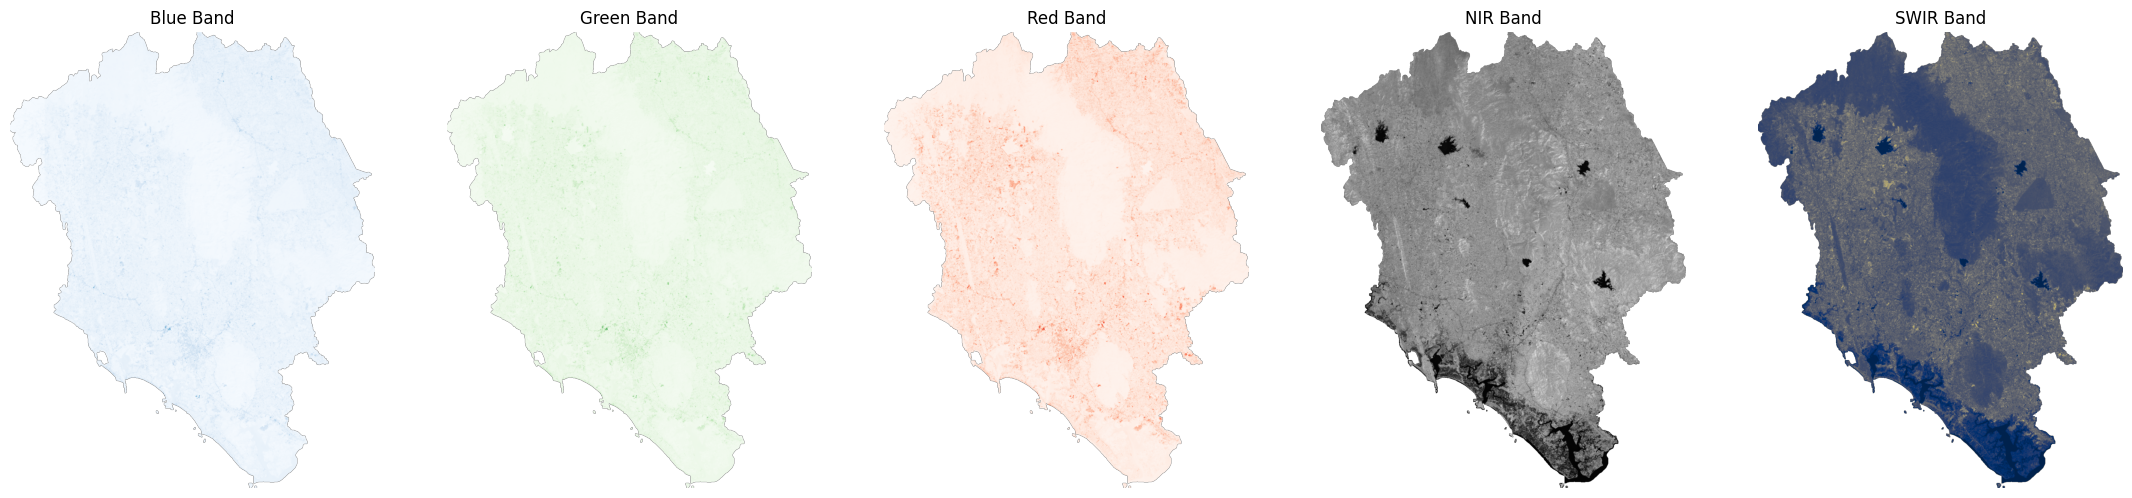

In [ ]:

def read_preview(src, band_index, scale=8):
    return src.read(
        band_index,
        out_shape=(max(1, src.height // scale), max(1, src.width // scale)),
        resampling=Resampling.average
    ).astype("float32")

with rasterio.open(RASTER_PATH) as src:
    blue_preview  = read_preview(src, BLUE_IDX, scale=8)
    green_preview = read_preview(src, GREEN_IDX, scale=8)
    red_preview   = read_preview(src, RED_IDX, scale=8)
    nir_preview   = read_preview(src, NIR_IDX, scale=8)
    swir_preview  = read_preview(src, SWIR_IDX, scale=8)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

preview_items = [
    (blue_preview, "Blue Band", "Blues"),
    (green_preview, "Green Band", "Greens"),
    (red_preview, "Red Band", "Reds"),
    (nir_preview, "NIR Band", "gray"),
    (swir_preview, "SWIR Band", "cividis"),
]

for ax, (img, title, cmap) in zip(axes, preview_items):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6) คำนวณดัชนีตัวอย่างแบบ downsample

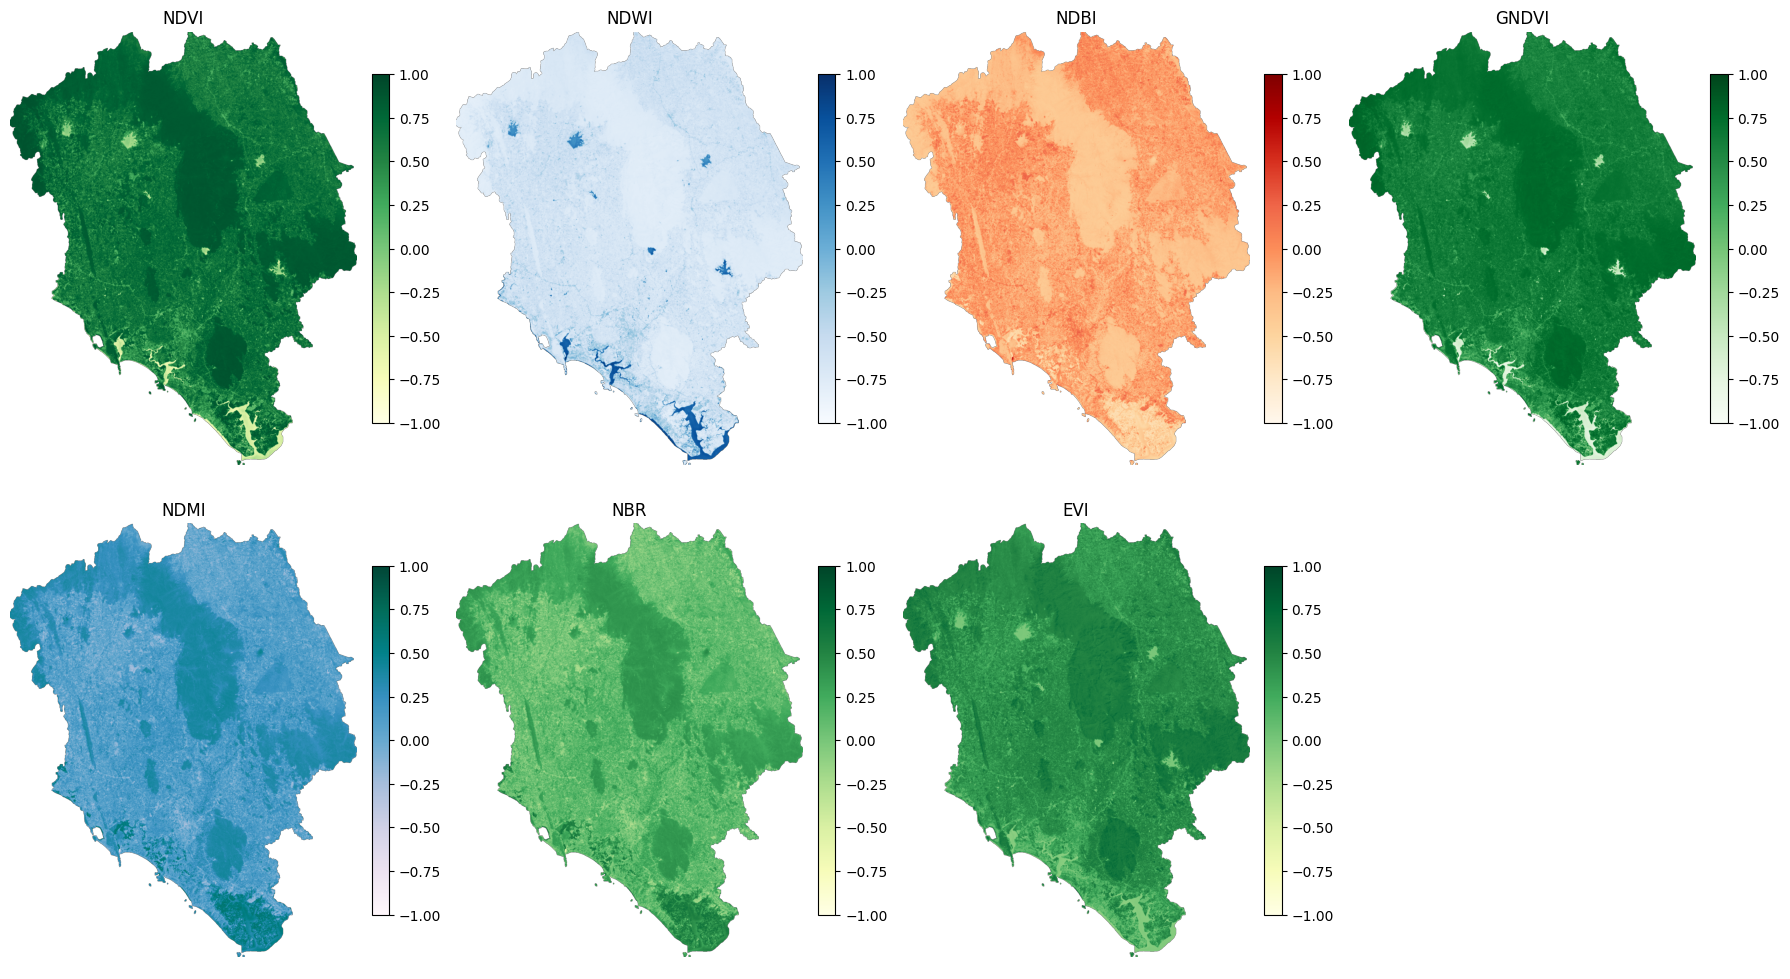

In [ ]:

def safe_index(a, b):
    denom = a + b
    out = np.where(denom == 0, np.nan, (a - b) / denom)
    return out.astype("float32")

def safe_divide(num, denom):
    out = np.where(denom == 0, np.nan, num / denom)
    return out.astype("float32")

ndvi_preview  = safe_index(nir_preview, red_preview)
ndwi_preview  = safe_index(green_preview, nir_preview)
ndbi_preview  = safe_index(swir_preview, nir_preview)
gndvi_preview = safe_index(nir_preview, green_preview)
ndmi_preview  = safe_index(nir_preview, swir_preview)
nbr_preview   = safe_index(nir_preview, swir_preview)
evi_preview   = safe_divide(2.5 * (nir_preview - red_preview),
                            (nir_preview + 6 * red_preview - 7.5 * blue_preview + 1))

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

plots = [
    (ndvi_preview, "NDVI", "YlGn"),
    (ndwi_preview, "NDWI", "Blues"),
    (ndbi_preview, "NDBI", "OrRd"),
    (gndvi_preview, "GNDVI", "Greens"),
    (ndmi_preview, "NDMI", "PuBuGn"),
    (nbr_preview, "NBR", "YlGn"),
    (evi_preview, "EVI", "YlGn")
]

for ax, (img, title, cmap) in zip(axes.ravel(), plots):
    im = ax.imshow(img, cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()



ดัชนีที่เพิ่มเข้ามาเพื่อช่วยแยกพื้นที่ป่าไม้ ได้แก่ **GNDVI, NDMI, NBR และ EVI**  
โดยเฉพาะ **EVI** และ **NDMI** มักช่วยแยกพื้นที่ที่มีเรือนยอดหนาแน่นและความชื้นสูงออกจากพื้นที่เกษตรกรรมหรือพืชพรรณเบาบางได้ดีขึ้น


## 7) โหลดข้อมูลจุดตัวอย่างจาก CSV และแปลงเป็น GeoDataFrame

In [ ]:

samples_df = pd.read_csv(SAMPLES_CSV)
display(samples_df.head())

required_cols = ["longitude", "latitude", "label"]
missing_cols = [c for c in required_cols if c not in samples_df.columns]
if missing_cols:
    raise ValueError(f"ไม่พบคอลัมน์ที่จำเป็น: {missing_cols}")

gdf = gpd.GeoDataFrame(
    samples_df.copy(),
    geometry=gpd.points_from_xy(samples_df["longitude"], samples_df["latitude"]),
    crs="EPSG:4326"
)

with rasterio.open(RASTER_PATH) as src:
    gdf = gdf.to_crs(src.crs)

display(gdf.head())
print("จำนวนจุดตัวอย่าง:", len(gdf))
print("จำนวนตัวอย่างต่อคลาส:")
display(gdf["label"].value_counts())


,longitude,latitude,label,source_area
0,102.257176,12.604397,urban,Chanthaburi_town
1,102.180738,12.859254,forest,Khao_Khitchakut_NP
2,102.184848,13.036030,forest,Khao_Soi_Dao_WS
3,102.009807,12.597244,agriculture,Tha_Mai_agri_belt
4,102.063150,12.497438,water,Laem_Sing_coast


,longitude,latitude,label,source_area,geometry
0,102.257176,12.604397,urban,Chanthaburi_town,POINT (853937.361 1395585.24)
1,102.180738,12.859254,forest,Khao_Khitchakut_NP,POINT (845277.783 1423705.821)
2,102.184848,13.036030,forest,Khao_Soi_Dao_WS,POINT (845480.28 1443287.643)
3,102.009807,12.597244,agriculture,Tha_Mai_agri_belt,POINT (827042.907 1394471.844)
4,102.063150,12.497438,water,Laem_Sing_coast,POINT (832972.578 1383487.773)


จำนวนจุดตัวอย่าง: 200
จำนวนตัวอย่างต่อคลาส:


,count
label,
urban,50
forest,50
agriculture,50
water,50


## 8) ดึงค่าของ band จากจุดตัวอย่าง แล้วคำนวณดัชนีเป็น features

In [ ]:

coords = [(geom.x, geom.y) for geom in gdf.geometry]

with rasterio.open(RASTER_PATH) as src:
    sampled_values = list(src.sample(coords, indexes=[BLUE_IDX, GREEN_IDX, RED_IDX, NIR_IDX, SWIR_IDX]))

sampled_arr = np.array(sampled_values, dtype="float32")

gdf["blue"]  = sampled_arr[:, 0]
gdf["green"] = sampled_arr[:, 1]
gdf["red"]   = sampled_arr[:, 2]
gdf["nir"]   = sampled_arr[:, 3]
gdf["swir"]  = sampled_arr[:, 4]

gdf["ndvi"]  = safe_index(gdf["nir"].values, gdf["red"].values)
gdf["ndwi"]  = safe_index(gdf["green"].values, gdf["nir"].values)
gdf["ndbi"]  = safe_index(gdf["swir"].values, gdf["nir"].values)
gdf["gndvi"] = safe_index(gdf["nir"].values, gdf["green"].values)
gdf["ndmi"]  = safe_index(gdf["nir"].values, gdf["swir"].values)
gdf["nbr"]   = safe_index(gdf["nir"].values, gdf["swir"].values)
gdf["evi"]   = safe_divide(
    2.5 * (gdf["nir"].values - gdf["red"].values),
    (gdf["nir"].values + 6 * gdf["red"].values - 7.5 * gdf["blue"].values + 1)
)

feature_cols = ["blue", "green", "red", "nir", "swir", "ndvi", "ndwi", "ndbi", "gndvi", "ndmi", "nbr", "evi"]
ml_df = pd.DataFrame(gdf.drop(columns="geometry")).replace([np.inf, -np.inf], np.nan)
ml_df = ml_df.dropna(subset=feature_cols + ["label"]).reset_index(drop=True)

print("ขนาดข้อมูลหลังเตรียม features:", ml_df.shape)
display(ml_df.head())


ขนาดข้อมูลหลังเตรียม features: (173, 16)


,longitude,latitude,label,source_area,blue,green,red,nir,swir,ndvi,ndwi,ndbi,gndvi,ndmi,nbr,evi
0,102.257176,12.604397,urban,Chanthaburi_town,0.06190,0.09260,0.11140,0.29470,0.2837,0.451367,-0.521818,-0.019018,0.521818,0.019018,0.019018,0.305734
1,102.180738,12.859254,forest,Khao_Khitchakut_NP,0.02675,0.04205,0.02375,0.37240,0.1471,0.880096,-0.797080,-0.433686,0.797080,0.433686,0.433686,0.663198
2,102.184848,13.036030,forest,Khao_Soi_Dao_WS,0.02490,0.04070,0.02190,0.32440,0.1258,0.873520,-0.777047,-0.441137,0.777047,0.441137,0.441137,0.595918
3,102.009807,12.597244,agriculture,Tha_Mai_agri_belt,0.14340,0.15820,0.18860,0.22540,0.2977,0.088889,-0.175182,0.138214,0.175182,-0.138214,-0.138214,0.071791
4,102.063150,12.497438,water,Laem_Sing_coast,0.05475,0.06070,0.02575,0.00835,0.0086,-0.510264,0.758146,0.014749,-0.758146,-0.014749,-0.014749,-0.057828


## 9) เตรียมข้อมูลสำหรับ Machine Learning

In [ ]:

X = ml_df[feature_cols].copy()
y = ml_df["label"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Features:", feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Classes: ['agriculture', 'forest', 'urban', 'water']
Features: ['blue', 'green', 'red', 'nir', 'swir', 'ndvi', 'ndwi', 'ndbi', 'gndvi', 'ndmi', 'nbr', 'evi']
Train size: (121, 12)
Test size : (52, 12)


## 10) สร้างและปรับแต่งโมเดล

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV Score:", rf_grid.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best RF CV Score: 0.6363333333333334


In [ ]:

svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_param_grid = {
    "model__C": [1, 10],
    "model__gamma": ["scale", 0.1],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV Score:", svm_grid.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best SVM Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVM CV Score: 0.628


## 11) เปรียบเทียบผลของโมเดลและเลือกโมเดลที่ดีที่สุด

In [ ]:

models = {
    "Random Forest": rf_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": model_name, "test_accuracy": acc})

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, "model"]
best_model = models[best_model_name]

print("Best Model on Test Set:", best_model_name)


,model,test_accuracy
0,Random Forest,0.596154
1,SVM,0.557692


Best Model on Test Set: Random Forest


## 12) ประเมินผลโมเดล

Accuracy = 0.5961538461538461


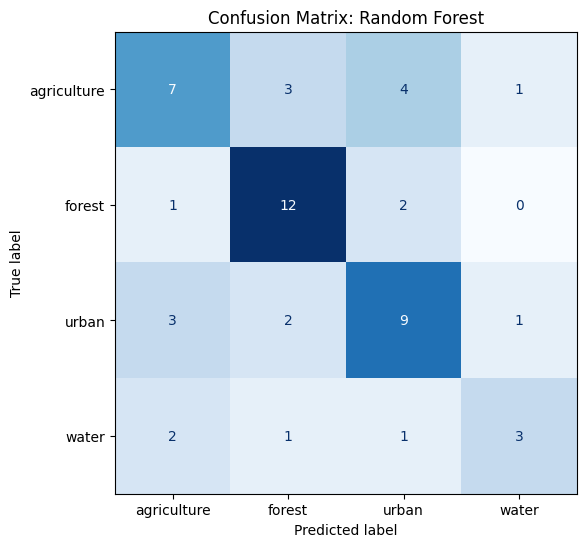

Classification Report
              precision    recall  f1-score   support

 agriculture       0.54      0.47      0.50        15
      forest       0.67      0.80      0.73        15
       urban       0.56      0.60      0.58        15
       water       0.60      0.43      0.50         7

    accuracy                           0.60        52
   macro avg       0.59      0.57      0.58        52
weighted avg       0.59      0.60      0.59        52



In [ ]:

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy =", acc)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


## 13) วิเคราะห์ความสำคัญของ Feature

,feature,importance
5,ndvi,0.151603
8,gndvi,0.097789
4,swir,0.097211
1,green,0.085176
0,blue,0.080644
2,red,0.075958
6,ndwi,0.073104
7,ndbi,0.072081
11,evi,0.068601
10,nbr,0.067834


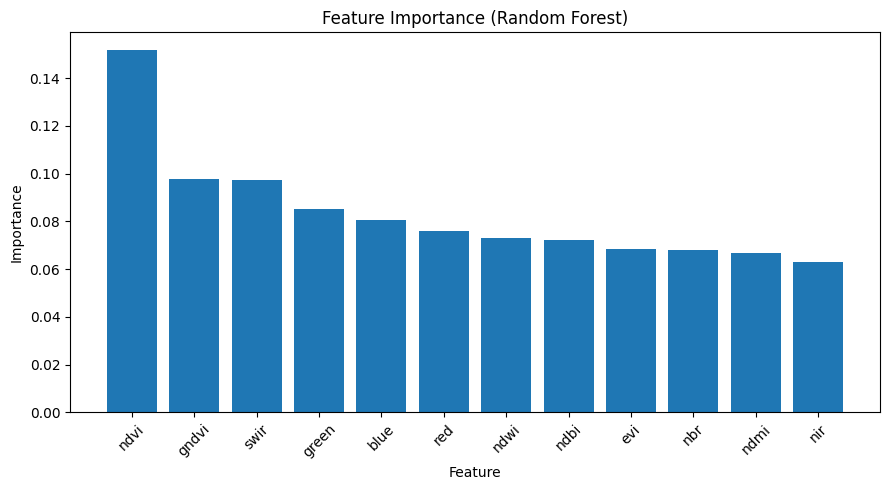

In [ ]:

if best_model_name == "Random Forest":
    rf_model = best_model.named_steps["model"]
    importances = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances)

    plt.figure(figsize=(9, 5))
    plt.bar(importances["feature"], importances["importance"])
    plt.title("Feature Importance (Random Forest)")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("โมเดลที่ดีที่สุดไม่ใช่ Random Forest จึงไม่สามารถดึง feature importance แบบตรง ๆ ได้")


## 14) ทำนายทั้งภาพแบบ block/tile และบันทึกผลลัพธ์

In [ ]:

OUTPUT_TIF = DATA_DIR / "classification_result_block.tif"
CLASS_MAP_JSON = DATA_DIR / "classification_result_block_classes.json"

out_meta = meta.copy()
out_meta.update({
    "count": 1,
    "dtype": "int16",
    "nodata": -1
})

with rasterio.open(RASTER_PATH) as src, rasterio.open(OUTPUT_TIF, "w", **out_meta) as dst:
    for _, window in src.block_windows(1):
        blue_w  = src.read(BLUE_IDX,  window=window).astype("float32")
        green_w = src.read(GREEN_IDX, window=window).astype("float32")
        red_w   = src.read(RED_IDX,   window=window).astype("float32")
        nir_w   = src.read(NIR_IDX,   window=window).astype("float32")
        swir_w  = src.read(SWIR_IDX,  window=window).astype("float32")

        ndvi_w  = safe_index(nir_w, red_w)
        ndwi_w  = safe_index(green_w, nir_w)
        ndbi_w  = safe_index(swir_w, nir_w)
        gndvi_w = safe_index(nir_w, green_w)
        ndmi_w  = safe_index(nir_w, swir_w)
        nbr_w   = safe_index(nir_w, swir_w)
        evi_w   = safe_divide(2.5 * (nir_w - red_w), (nir_w + 6 * red_w - 7.5 * blue_w + 1))

        stack_w = np.stack(
            [blue_w, green_w, red_w, nir_w, swir_w, ndvi_w, ndwi_w, ndbi_w, gndvi_w, ndmi_w, nbr_w, evi_w],
            axis=-1
        )

        valid_mask = np.all(np.isfinite(stack_w), axis=-1)

        H, W, F = stack_w.shape
        flat = stack_w.reshape(-1, F)
        flat_valid = valid_mask.reshape(-1)

        classified_block = np.full(H * W, fill_value=-1, dtype=np.int16)

        if np.any(flat_valid):
            pred_block = best_model.predict(flat[flat_valid]).astype(np.int16)
            classified_block[flat_valid] = pred_block

        classified_block = classified_block.reshape(H, W)
        dst.write(classified_block, 1, window=window)

class_map = {int(i): cls for i, cls in enumerate(label_encoder.classes_)}
with open(CLASS_MAP_JSON, "w", encoding="utf-8") as f:
    json.dump(class_map, f, ensure_ascii=False, indent=2)

print("บันทึกไฟล์แล้ว:", OUTPUT_TIF)
print("บันทึก class map แล้ว:", CLASS_MAP_JSON)
print("Class map:", class_map)


บันทึกไฟล์แล้ว: /content/drive/MyDrive/BackupRSProject/Study_area/classification_result_block.tif
บันทึก class map แล้ว: /content/drive/MyDrive/BackupRSProject/Study_area/classification_result_block_classes.json
Class map: {0: 'agriculture', 1: 'forest', 2: 'urban', 3: 'water'}


## 15) แสดงผลแผนที่การจำแนกจากไฟล์ผลลัพธ์

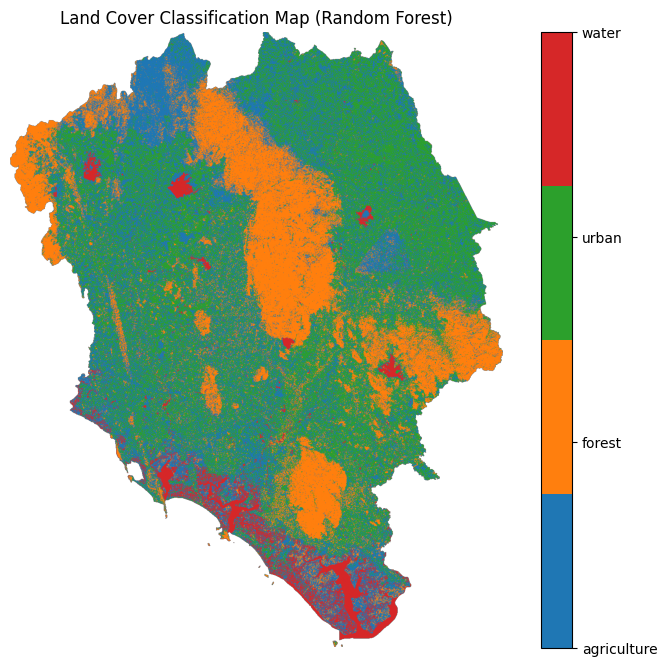

In [ ]:

with rasterio.open(OUTPUT_TIF) as src:
    classified_preview = src.read(
        1,
        out_shape=(max(1, src.height // 8), max(1, src.width // 8)),
        resampling=Resampling.nearest
    )

class_names = list(label_encoder.classes_)
num_classes = len(class_names)
cmap = ListedColormap(plt.cm.tab10.colors[:num_classes])

plt.figure(figsize=(10, 8))
img = plt.imshow(np.where(classified_preview == -1, np.nan, classified_preview), cmap=cmap, vmin=0, vmax=num_classes - 1)
plt.title(f"Land Cover Classification Map ({best_model_name})")
plt.axis("off")

cbar = plt.colorbar(img, ticks=np.arange(num_classes))
cbar.ax.set_yticklabels(class_names)

plt.show()



## 16) สรุปผลการทดลอง

การทดลองนี้ใช้ข้อมูล Sentinel-2 ของจังหวัดจันทบุรี โดยเลือกแบนด์สำคัญคือ B2, B3, B4, B8 และ B11 ร่วมกับดัชนีเชิงสเปกตรัมหลายตัว ได้แก่ NDVI, NDWI, NDBI, GNDVI, NDMI, NBR และ EVI เพื่อนำมาเป็น features สำหรับจำแนกพื้นที่ 4 ประเภทคือ เกษตรกรรม ป่าไม้ เมือง และแหล่งน้ำ

หลังจากดึงค่าจากจุดตัวอย่างและทำความสะอาดข้อมูลแล้ว เหลือข้อมูลที่ใช้จริง 173 ตัวอย่าง จากนั้นแบ่งเป็นชุดฝึก 121 ตัวอย่าง และชุดทดสอบ 52 ตัวอย่าง

เมื่อเปรียบเทียบโมเดล พบว่า

- Random Forest ให้ **Test Accuracy = 0.596154**
- SVM ให้ **Test Accuracy = 0.557692**

จึงเลือก Random Forest เป็นโมเดลที่ดีที่สุดในงานนี้ โดยมีพารามิเตอร์ที่ดีที่สุดคือ

- `n_estimators = 100`
- `max_depth = None`
- `min_samples_split = 5`
- `min_samples_leaf = 1`

ในด้านการแยกคลาส พบว่าโมเดลแยก `forest` ได้ดีที่สุด โดยมี Recall = 0.80 และ F1-score = 0.73 ซึ่งสอดคล้องกับวัตถุประสงค์ของงานที่เน้นการใช้ดัชนีช่วยแยกพื้นที่ป่าไม้ ส่วนคลาส `water` ยังมี Recall ต่ำกว่าเพื่อน สะท้อนว่าพื้นที่น้ำยังเกิดความสับสนกับลักษณะพื้นที่อื่นบางส่วน

โดยรวมแล้ว โมเดลนี้ยังไม่ใช่โมเดลที่มีความแม่นยำสูงมากในระดับใช้งานเชิงปฏิบัติจริงทันที แต่ถือว่าแสดงให้เห็นกระบวนการทำงานครบถ้วนและอธิบายเหตุผลของผลลัพธ์ได้อย่างสมเหตุสมผล



## 17) คำตอบคำถามท้าย Lab

**1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?**  
เพราะ feature ที่เหมาะสมช่วยให้โมเดลเรียนรู้ความแตกต่างของแต่ละคลาสได้ชัดเจนขึ้น ลดสัญญาณรบกวน และช่วยเพิ่มความแม่นยำในการทำนาย หากเลือก feature ที่ไม่เหมาะสม โมเดลอาจเกิด overfitting หรือแยกคลาสได้ไม่ดี

**2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้**  
**Random Forest** เหมาะกับงานจำแนกข้อมูลภาพถ่ายดาวเทียมเพราะรองรับความสัมพันธ์แบบไม่เชิงเส้นได้ดี ทนต่อ noise ได้ดี และสามารถบอกความสำคัญของ Feature ได้ ทำให้ตีความผลได้ง่ายกว่า  
ส่วน **SVM** มักให้ผลดีเมื่อข้อมูลมีจำนวนไม่มากและ class แยกกันได้ชัด โดยเฉพาะเมื่อใช้ kernel ที่เหมาะสม แต่ SVM ไวต่อการปรับสเกลข้อมูลและการเลือกพารามิเตอร์ เช่น `C` และ `gamma` มากกว่า Random Forest  
ดังนั้น หากต้องการโมเดลที่ใช้งานง่ายและตีความได้ดี Random Forest มักเป็นตัวเลือกที่เหมาะกว่า แต่ถ้าข้อมูลมีรูปแบบที่ซับซ้อนและปรับพารามิเตอร์ได้เหมาะสม SVM ก็อาจให้ผลลัพธ์ที่ดีมากเช่นกัน
Random Forest เหมาะกับข้อมูลที่มีหลาย feature และสามารถอธิบายความสำคัญของตัวแปรได้ง่าย ส่วน SVM มีจุดเด่นในการสร้างเส้นแบ่งคลาสที่ชัดเจน โดยเฉพาะเมื่อใช้ kernel ที่เหมาะสม แต่ต้องอาศัยการปรับสเกลข้อมูลและการจูนพารามิเตอร์อย่างเหมาะสม

**3. การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?**  
ไม่เพียงพอ เพราะ NDVI เน้นการวัดความเขียวของพืชพรรณเป็นหลัก จึงเหมาะกับการแยกพื้นที่ที่มีพืชและไม่มีพืช แต่ไม่เพียงพอสำหรับแยกพื้นที่ที่มีลักษณะคล้ายกัน เช่น ป่าไม้กับพื้นที่เกษตรบางประเภท หรือเขตเมืองกับพื้นที่โล่งบางชนิด ในงานนี้จึงเพิ่ม **EVI, GNDVI, NDMI และ NBR** เพื่อช่วยแยกป่าไม้โดยอาศัยทั้งความหนาแน่นของเรือนยอดและความชื้นของพืชพรรณร่วมกัน

**4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?**  
สามารถเพิ่มจำนวนจุดตัวอย่างที่ตรวจสอบแล้วจากภาพจริง ปรับปรุงคุณภาพของข้อมูล เลือก feature ที่เหมาะสมมากขึ้น ทดลองโมเดลหลายชนิด และปรับพารามิเตอร์ของโมเดลด้วย Grid Search สามารถเพิ่มความแม่นยำได้หลายวิธี เช่น
- เพิ่มจำนวนและคุณภาพของจุดตัวอย่างให้ครอบคลุมทุก class มากขึ้น
- เลือก Feature ที่เหมาะสมมากขึ้น หรือสร้างดัชนีเพิ่มเติม เช่น EVI, GNDVI, NDMI และ NBR
- ปรับพารามิเตอร์ของโมเดลด้วย Grid Search หรือวิธีอื่น
- ทดลองหลายโมเดลแล้วเปรียบเทียบผล
- จัดการข้อมูลรบกวน เช่น เมฆ เงา หรือค่าผิดปกติ
- ใช้ข้อมูลหลายช่วงเวลา (multi-temporal) เพื่อช่วยแยก class ที่มีลักษณะคล้ายกัน

**5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?**  
จุดตัวอย่างอาจคลาดเคลื่อนจากตำแหน่งจริง ภาพอาจมีเมฆหรือสัญญาณรบกวน ความละเอียดเชิงพื้นที่อาจไม่เพียงพอ คลาสอาจไม่สมดุล และบางพื้นที่อาจมีลักษณะสเปกตรัมใกล้เคียงกัน ตัวอย่างปัจจัยที่ทำให้เกิดความผิดพลาดได้ เช่น
- จุดตัวอย่างมีการระบุ class ผิด
- จำนวนตัวอย่างของแต่ละ class ไม่สมดุล
- ความละเอียดของภาพไม่เหมาะกับขนาดของวัตถุบนพื้นดิน
- มีเมฆ เงา หรือสัญญาณรบกวนในภาพ
- แต่ละ class มีลักษณะสเปกตรัมใกล้เคียงกัน
- ใช้ Feature ไม่เพียงพอหรือไม่เหมาะสม
- โมเดลเกิด overfitting หรือ underfitting
